In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download salader/dogsvscats -p data --unzip -o -q

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown


In [33]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [34]:
# train_ds = keras.utils.image_dataset_from_directory(
#     directory='/content/data/train',
#     labels='inferred',
#     label_mode='int',
#     batch_size=32,
#     image_size=(256,256)
# )

# val_ds = keras.utils.image_dataset_from_directory(
#     directory='/content/data/test',
#     labels='inferred',
#     label_mode='int',
#     batch_size=32,
#     image_size=(256,256)
# )

In [45]:
batch_size = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    directory='/content/data/train',
    target_size=(256,256),
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = test_datagen.flow_from_directory(
    directory='/content/data/test',
    target_size=(256,256),
    batch_size=batch_size,
    class_mode='binary'
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [46]:
print(len(train_generator))
print(len(val_generator))

1250
313


In [36]:
# #Normalize
# def process(image, label):
#   image = tf.cast(image/255. , tf.float32)
#   return image, label

# train_ds = train_ds.map(process)
# val_ds = val_ds.map(process)

In [47]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [49]:
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

In [50]:
# history = model.fit(train_ds, epochs=10, validation_data=val_ds)

In [51]:
history = model.fit(
    train_generator,
    steps_per_epoch= 20000 // batch_size,
    epochs=20,
    validation_data=val_generator,
    validation_steps= 5000 // batch_size
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 321s 250ms/step - accuracy: 0.5570 - loss: 3.8477 - val_accuracy: 0.5940 - val_loss: 0.6490
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 312s 249ms/step - accuracy: 0.6996 - loss: 0.5966 - val_accuracy: 0.7314 - val_loss: 1.1533
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 311s 249ms/step - accuracy: 0.7582 - loss: 0.5331 - val_accuracy: 0.7492 - val_loss: 0.5361
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 311s 249ms/step - accuracy: 0.7878 - loss: 0.4996 - val_accuracy: 0.7015 - val_loss: 0.7931
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 312s 250ms/step - accuracy: 0.8067 - loss: 0.4651 - val_accuracy: 0.7680 - val_loss: 0.6035
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 314s 251ms/step - accuracy: 0.8188 - loss: 0.4370 - val_accuracy: 0.7786 - val_loss: 0.4893
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 311s 249ms/step - accuracy: 0.8310 - loss: 0.4226 - val_accuracy: 0.7278 - val_loss: 0.5674
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 316s 253ms/step - ac

KeyboardInterrupt: 

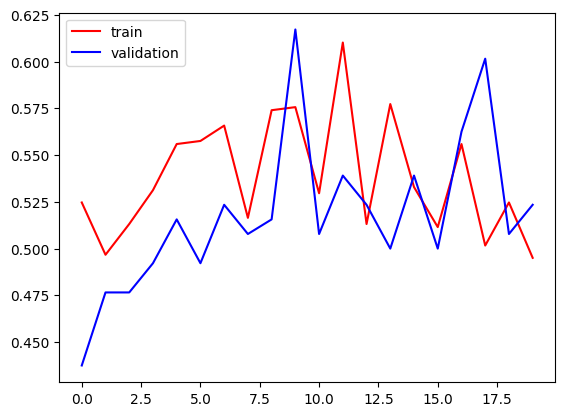

In [52]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

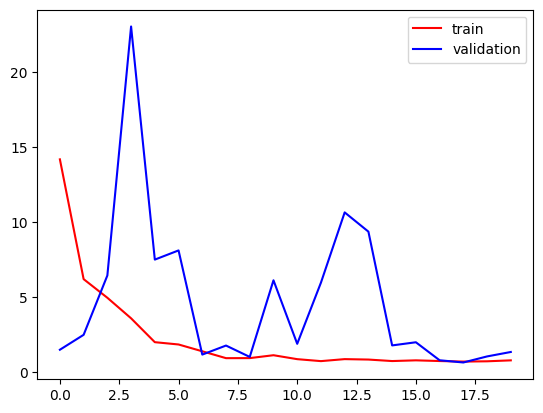

In [53]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()